In [1]:
# =============================================================================
# PB2-06: Feature Engineering Pipeline
# Offshore Wind Energy Forecasting - Group 3
# =============================================================================
# This notebook transforms cleaned KNMI weather data into model-ready features.
# Run this AFTER preprocessing, BEFORE model training (PB2-04).
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

In [2]:
# ── Load cleaned KNMI dataset ─────────────────────────────────────────────────
# Make sure this path points to your cleaned file from Sprint 1
knmi = pd.read_csv("../datasets/knmi_209_2011_2020_cleaned.csv", parse_dates=["timestamp"], index_col="timestamp") #knmi_209_2011_2020_cleaned

print("KNMI dataset loaded.")
print(f"  Shape: {knmi.shape}")
print(f"  Columns: {list(knmi.columns)}")
print(f"  Date range: {knmi.index.min()} → {knmi.index.max()}")
print()


KNMI dataset loaded.
  Shape: (85400, 8)
  Columns: ['wind_direction_deg', 'wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'pressure_hpa', 'humidity_pct', 'precipitation_mm']
  Date range: 2011-01-01 02:00:00 → 2021-01-01 01:00:00



In [3]:
# ── Preview raw data ──────────────────────────────────────────────────────────
print("── Raw Data Preview ─────────────────────────────────────────────────────")
display(knmi[["wind_direction_deg", "wind_speed_ms"]].head(5).style
        .set_caption("Raw Input Data (first 5 rows)")
        .format({"wind_direction_deg": "{:.1f}°", "wind_speed_ms": "{:.2f} m/s"})
        .background_gradient(cmap="Blues"))

── Raw Data Preview ─────────────────────────────────────────────────────


,wind_direction_deg,wind_speed_ms
timestamp,,
2011-01-01 02:00:00,260.0°,7.00 m/s
2011-01-01 03:00:00,270.0°,7.00 m/s
2011-01-01 04:00:00,260.0°,8.00 m/s
2011-01-01 05:00:00,260.0°,7.00 m/s
2011-01-01 06:00:00,270.0°,7.00 m/s


In [4]:
# =============================================================================
# FEATURE 1: Wind Direction Encoding (sin / cos)
# =============================================================================
# Problem: raw degrees (0–360) are circular. 1° and 359° are almost the same
# direction but numerically 358 apart. A model would treat them as opposites.
# Fix: decompose into two continuous components using trigonometry.
# =============================================================================

print("── Feature 1: Wind Direction Encoding ──────────────────────────────────")

knmi["wind_dir_sin"] = np.sin(np.radians(knmi["wind_direction_deg"]))
knmi["wind_dir_cos"] = np.cos(np.radians(knmi["wind_direction_deg"]))

# Verify: 0° and 360° should produce identical results
assert np.isclose(np.sin(np.radians(0)), np.sin(np.radians(360))), "Encoding check failed"
print("  wind_dir_sin and wind_dir_cos created.")
print(f"  Sample — 180° → sin={np.sin(np.radians(180)):.3f}, cos={np.cos(np.radians(180)):.3f} (expected: 0, -1)")
print(f"  Sample — 90°  → sin={np.sin(np.radians(90)):.3f}, cos={np.cos(np.radians(90)):.3f}  (expected: 1, 0)")
print()


── Feature 1: Wind Direction Encoding ──────────────────────────────────
  wind_dir_sin and wind_dir_cos created.
  Sample — 180° → sin=0.000, cos=-1.000 (expected: 0, -1)
  Sample — 90°  → sin=1.000, cos=0.000  (expected: 1, 0)



In [5]:
# =============================================================================
# FEATURE 2: Hub Height Wind Speed Extrapolation (Power Law)
# =============================================================================
# Problem: KNMI measures wind at 10m. Offshore turbines operate at ~120m.
# Wind increases with height. Using 10m values underestimates turbine input.
# Fix: apply the wind power law  v_hub = v_10m * (h_hub / h_ref) ^ alpha
#
# alpha = 0.11 is the standard offshore roughness exponent (smooth sea surface).
# This is lower than onshore (~0.14–0.20) because the sea has less friction.
# =============================================================================

print("── Feature 2: Hub Height Wind Speed Extrapolation ──────────────────────")

H_REF  = 10    # KNMI measurement height (meters)
H_HUB  = 120   # Turbine hub height (meters) — from your Offshore dataset metadata
ALPHA  = 0.11  # Offshore power law exponent

scaling_factor = (H_HUB / H_REF) ** ALPHA
print(f"  Scaling factor: ({H_HUB}m / {H_REF}m)^{ALPHA} = {scaling_factor:.4f}")
print(f"  → A 10 m/s reading at 10m becomes {10 * scaling_factor:.2f} m/s at {H_HUB}m")

knmi["wind_speed_hub_ms"] = knmi["wind_speed_ms"] * scaling_factor

# Compare distributions
print(f"\n  Mean wind speed at 10m:  {knmi['wind_speed_ms'].mean():.2f} m/s")
print(f"  Mean wind speed at hub:  {knmi['wind_speed_hub_ms'].mean():.2f} m/s")
print(f"  Observed offshore mean was ~9.2 m/s — how close are we?")
print()

── Feature 2: Hub Height Wind Speed Extrapolation ──────────────────────
  Scaling factor: (120m / 10m)^0.11 = 1.3143
  → A 10 m/s reading at 10m becomes 13.14 m/s at 120m

  Mean wind speed at 10m:  7.33 m/s
  Mean wind speed at hub:  9.63 m/s
  Observed offshore mean was ~9.2 m/s — how close are we?



In [6]:
# =============================================================================
# FEATURE 3: Wind Power Density (v³)
# =============================================================================
# The theoretical power available in wind is proportional to v³ (wind speed cubed).
# This is derived from the kinetic energy formula: P = 0.5 * rho * A * v³
# Adding this as a feature helps the model capture the non-linear relationship
# between wind speed and power output (the S-curve you already found).
# =============================================================================

print("── Feature 3: Wind Power Density ───────────────────────────────────────")

knmi["wind_power_density"] = knmi["wind_speed_hub_ms"] ** 3

print("  wind_power_density = wind_speed_hub_ms³ created.")
print(f"  Mean: {knmi['wind_power_density'].mean():.1f}  |  Max: {knmi['wind_power_density'].max():.1f}")
print()

── Feature 3: Wind Power Density ───────────────────────────────────────
  wind_power_density = wind_speed_hub_ms³ created.
  Mean: 1571.2  |  Max: 39907.1



In [7]:
# =============================================================================
# FEATURE 4: Lag Features
# =============================================================================
# Problem: wind energy at hour X depends on conditions in the past few hours.
# Atmospheric systems evolve over hours — adding lagged values gives the model
# a "memory" of recent conditions.
# =============================================================================

print("── Feature 4: Lag Features ──────────────────────────────────────────────")

LAG_HOURS = [1, 2, 3, 6, 12, 24]

for lag in LAG_HOURS:
    knmi[f"wind_speed_lag_{lag}h"] = knmi["wind_speed_hub_ms"].shift(lag)

print(f"  Created lag features for: {LAG_HOURS} hours")
print(f"  Note: first {max(LAG_HOURS)} rows will have NaN — these will be dropped later.")
print()


── Feature 4: Lag Features ──────────────────────────────────────────────
  Created lag features for: [1, 2, 3, 6, 12, 24] hours
  Note: first 24 rows will have NaN — these will be dropped later.



In [8]:
# =============================================================================
# FEATURE 5: Rolling Averages (Smoothed Wind Speed)
# =============================================================================
# Problem: hourly wind speed is noisy. A single gusty hour should not dominate.
# Rolling averages capture the sustained wind conditions over a window.
# =============================================================================

print("── Feature 5: Rolling Averages ──────────────────────────────────────────")

ROLLING_WINDOWS = [3, 6, 12, 24]

for window in ROLLING_WINDOWS:
    knmi[f"wind_speed_roll_{window}h"] = (
        knmi["wind_speed_hub_ms"].rolling(window=window, min_periods=window).mean()
    )

print(f"  Created rolling averages for windows: {ROLLING_WINDOWS} hours")
print()


── Feature 5: Rolling Averages ──────────────────────────────────────────
  Created rolling averages for windows: [3, 6, 12, 24] hours



In [9]:
# FEATURE 6: Time-Based Features (Cyclically Encoded)
# =============================================================================
# Problem: seasonal and daily patterns exist (winter = more wind, summer = less).
# The model needs to understand time, but months and hours are also circular:
# December (12) and January (1) should be "close", not 11 apart.
# Fix: same sin/cos trick used for wind direction.
# =============================================================================

print("── Feature 6: Time Features ─────────────────────────────────────────────")

knmi["hour"]  = knmi.index.hour
knmi["month"] = knmi.index.month

# Cyclical encoding
knmi["hour_sin"]  = np.sin(2 * np.pi * knmi["hour"]  / 24)
knmi["hour_cos"]  = np.cos(2 * np.pi * knmi["hour"]  / 24)
knmi["month_sin"] = np.sin(2 * np.pi * knmi["month"] / 12)
knmi["month_cos"] = np.cos(2 * np.pi * knmi["month"] / 12)

# Season label (useful for grouping in analysis)
def get_season(month):
    if month in [12, 1, 2]:  return "Winter"
    elif month in [3, 4, 5]:  return "Spring"
    elif month in [6, 7, 8]:  return "Summer"
    else:                      return "Autumn"

knmi["season"] = knmi["month"].map(get_season)

print("  Created: hour_sin, hour_cos, month_sin, month_cos, season")
print()

── Feature 6: Time Features ─────────────────────────────────────────────
  Created: hour_sin, hour_cos, month_sin, month_cos, season



In [10]:
# =============================================================================
# CLEANUP: Drop rows with NaN — only check columns that actually have data
# =============================================================================
# NOTE: Station 209 has no temperature, pressure, humidity or precipitation.
# Those columns are 100% NaN by design. We only drop rows where the actual
# wind columns are missing, otherwise everything gets dropped.
# =============================================================================

print("── Cleanup ──────────────────────────────────────────────────────────────")

rows_before = len(knmi)

knmi_clean = knmi.dropna(subset=[
    "wind_speed_ms",
    "wind_direction_deg",
    "wind_speed_hub_ms",
    "wind_power_density",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_speed_lag_24h",    # longest lag — ensures all lag columns are present
    "wind_speed_roll_24h",   # longest rolling window
])

rows_after = len(knmi_clean)

print(f"  Rows before dropna: {rows_before}")
print(f"  Rows after dropna:  {rows_after}")
print(f"  Rows dropped:       {rows_before - rows_after}  (lag/rolling warmup period)")
print()



── Cleanup ──────────────────────────────────────────────────────────────
  Rows before dropna: 85400
  Rows after dropna:  85326
  Rows dropped:       74  (lag/rolling warmup period)



In [11]:
# =============================================================================
# SUMMARY: All engineered features
# =============================================================================

feature_cols = [
    "wind_dir_sin", "wind_dir_cos",
    "wind_speed_hub_ms", "wind_power_density",
    "wind_speed_lag_1h", "wind_speed_lag_2h", "wind_speed_lag_3h",
    "wind_speed_lag_6h", "wind_speed_lag_12h", "wind_speed_lag_24h",
    "wind_speed_roll_3h", "wind_speed_roll_6h",
    "wind_speed_roll_12h", "wind_speed_roll_24h",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

print("── All Engineered Features ──────────────────────────────────────────────")
for f in feature_cols:
    print(f"  {f:<30} — mean: {knmi_clean[f].mean():.4f}, std: {knmi_clean[f].std():.4f}")
print()


── All Engineered Features ──────────────────────────────────────────────
  wind_dir_sin                   — mean: -0.1457, std: 0.6906
  wind_dir_cos                   — mean: -0.1227, std: 0.6977
  wind_speed_hub_ms              — mean: 9.6362, std: 4.6170
  wind_power_density             — mean: 1572.3344, std: 2257.2421
  wind_speed_lag_1h              — mean: 9.6356, std: 4.6177
  wind_speed_lag_2h              — mean: 9.6350, std: 4.6184
  wind_speed_lag_3h              — mean: 9.6349, std: 4.6185
  wind_speed_lag_6h              — mean: 9.6343, std: 4.6191
  wind_speed_lag_12h             — mean: 9.6342, std: 4.6187
  wind_speed_lag_24h             — mean: 9.6348, std: 4.6182
  wind_speed_roll_3h             — mean: 9.6356, std: 4.5306
  wind_speed_roll_6h             — mean: 9.6351, std: 4.4279
  wind_speed_roll_12h            — mean: 9.6347, std: 4.2374
  wind_speed_roll_24h            — mean: 9.6345, std: 3.9149
  hour_sin                       — mean: -0.0001, std: 0.7071
  

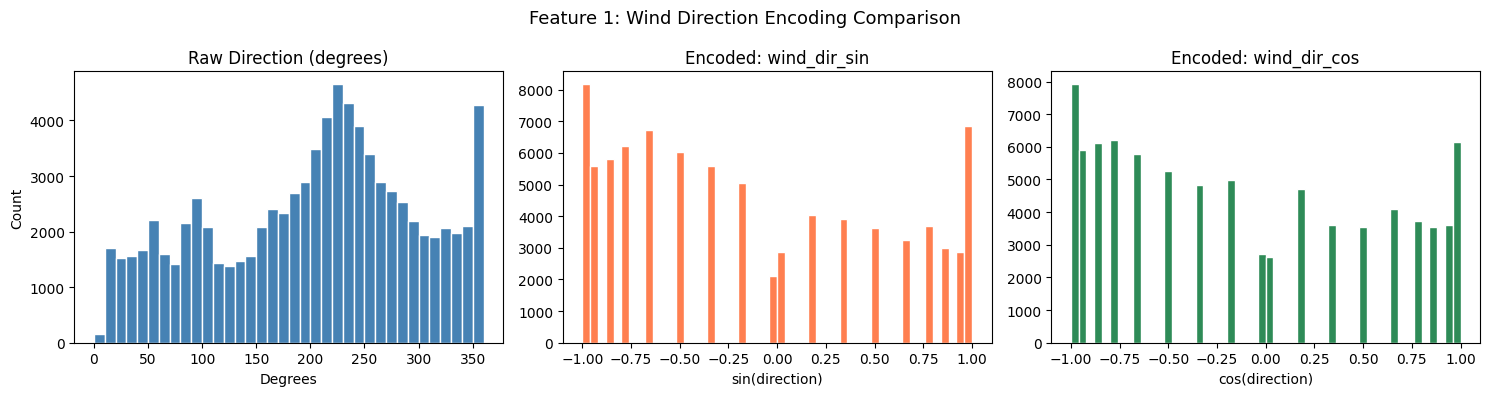

  Saved: feature_engineering_direction.png



In [12]:
# =============================================================================
# VISUALIZATION 1: Wind Direction — Raw vs Encoded
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Feature 1: Wind Direction Encoding Comparison", fontsize=13)

axes[0].hist(knmi_clean["wind_direction_deg"].dropna(), bins=36, color="steelblue", edgecolor="white")
axes[0].set_title("Raw Direction (degrees)")
axes[0].set_xlabel("Degrees")
axes[0].set_ylabel("Count")

axes[1].hist(knmi_clean["wind_dir_sin"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Encoded: wind_dir_sin")
axes[1].set_xlabel("sin(direction)")

axes[2].hist(knmi_clean["wind_dir_cos"], bins=50, color="seagreen", edgecolor="white")
axes[2].set_title("Encoded: wind_dir_cos")
axes[2].set_xlabel("cos(direction)")

plt.tight_layout()
plt.savefig("feature_engineering_direction.png", dpi=120)
plt.show()
print("  Saved: feature_engineering_direction.png")
print()


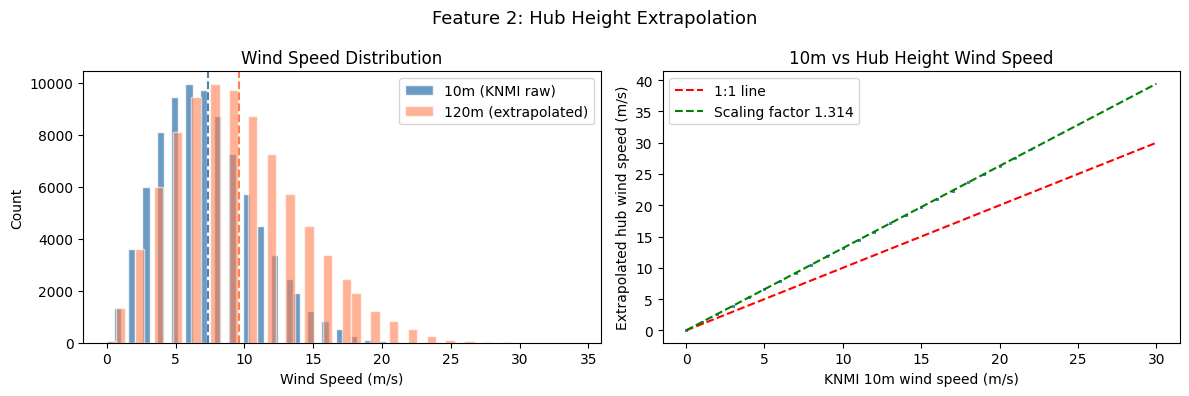

  Saved: feature_engineering_hubheight.png



In [13]:
# =============================================================================
# VISUALIZATION 2: Hub Height Extrapolation — Before vs After
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Feature 2: Hub Height Extrapolation", fontsize=13)

axes[0].hist(knmi_clean["wind_speed_ms"], bins=50, color="steelblue", edgecolor="white", alpha=0.8, label="10m (KNMI raw)")
axes[0].hist(knmi_clean["wind_speed_hub_ms"], bins=50, color="coral", edgecolor="white", alpha=0.6, label="120m (extrapolated)")
axes[0].axvline(knmi_clean["wind_speed_ms"].mean(), color="steelblue", linestyle="--", linewidth=1.5)
axes[0].axvline(knmi_clean["wind_speed_hub_ms"].mean(), color="coral", linestyle="--", linewidth=1.5)
axes[0].set_title("Wind Speed Distribution")
axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(knmi_clean["wind_speed_ms"], knmi_clean["wind_speed_hub_ms"],
                alpha=0.05, s=1, color="steelblue")
axes[1].plot([0, 30], [0, 30], "r--", linewidth=1.5, label="1:1 line")
axes[1].plot([0, 30], [0, 30 * scaling_factor], "g--", linewidth=1.5,
             label=f"Scaling factor {scaling_factor:.3f}")
axes[1].set_title("10m vs Hub Height Wind Speed")
axes[1].set_xlabel("KNMI 10m wind speed (m/s)")
axes[1].set_ylabel("Extrapolated hub wind speed (m/s)")
axes[1].legend()

plt.tight_layout()
plt.savefig("feature_engineering_hubheight.png", dpi=120)
plt.show()
print("  Saved: feature_engineering_hubheight.png")
print()


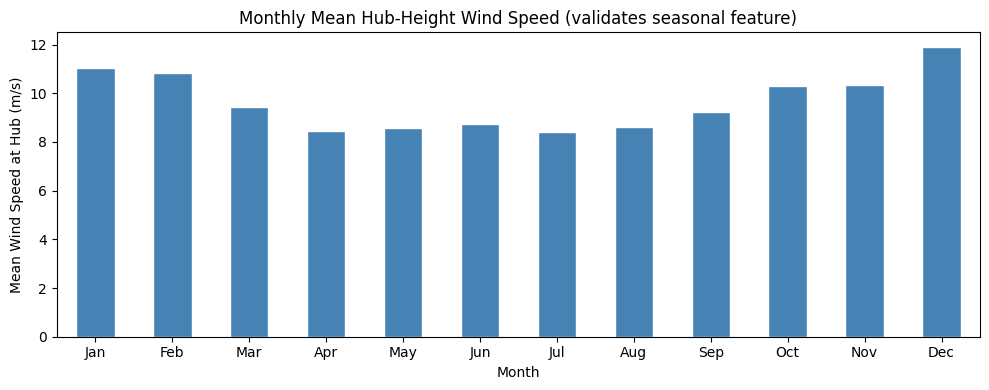

  Saved: feature_engineering_seasonal.png



In [14]:
# =============================================================================
# VISUALIZATION 3: Seasonal Pattern (validates time features)
# =============================================================================

monthly_mean = knmi_clean.groupby("month")["wind_speed_hub_ms"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_mean.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Monthly Mean Hub-Height Wind Speed (validates seasonal feature)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Wind Speed at Hub (m/s)")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                   rotation=0)
plt.tight_layout()
plt.savefig("feature_engineering_seasonal.png", dpi=120)
plt.show()
print("  Saved: feature_engineering_seasonal.png")
print()

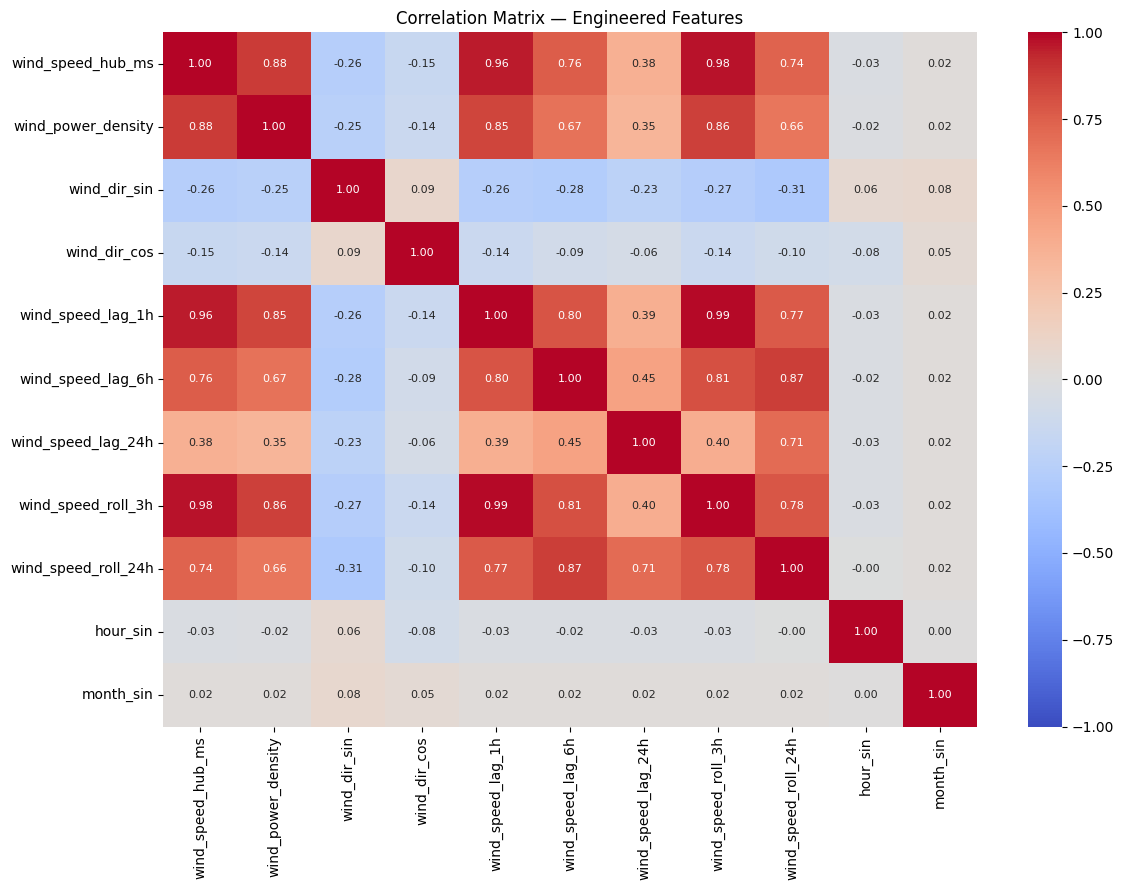

  Saved: feature_engineering_correlation.png



In [15]:
# =============================================================================
# VISUALIZATION 4: Correlation matrix of all engineered features
# =============================================================================
# This shows which features are related to each other (multicollinearity)
# and helps justify which ones to keep for the model in PB2-04.
# =============================================================================

corr_cols = [
    "wind_speed_hub_ms", "wind_power_density",
    "wind_dir_sin", "wind_dir_cos",
    "wind_speed_lag_1h", "wind_speed_lag_6h", "wind_speed_lag_24h",
    "wind_speed_roll_3h", "wind_speed_roll_24h",
    "hour_sin", "month_sin",
]

corr_matrix = knmi_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Engineered Features")
plt.tight_layout()
plt.savefig("feature_engineering_correlation.png", dpi=120)
plt.show()
print("  Saved: feature_engineering_correlation.png")
print()


In [16]:
# =============================================================================
# SAVE: Export the feature-engineered dataset
# =============================================================================

output_path = Path("../feature_engineering/knmi_209_2011_2020_feature_engineering.csv")
knmi_clean.to_csv(output_path)

print(f"── Saved engineered dataset ─────────────────────────────────────────────")
print(f"  Path: {output_path}")
print(f"  Shape: {knmi_clean.shape}")
print(f"  Columns ({len(knmi_clean.columns)}): {list(knmi_clean.columns)}")
print()
print("  ✓ Feature engineering complete. Ready for PB2-04 model training.")

── Saved engineered dataset ─────────────────────────────────────────────
  Path: ../feature_engineering/knmi_209_2011_2020_feature_engineering.csv
  Shape: (85326, 29)
  Columns (29): ['wind_direction_deg', 'wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'pressure_hpa', 'humidity_pct', 'precipitation_mm', 'wind_dir_sin', 'wind_dir_cos', 'wind_speed_hub_ms', 'wind_power_density', 'wind_speed_lag_1h', 'wind_speed_lag_2h', 'wind_speed_lag_3h', 'wind_speed_lag_6h', 'wind_speed_lag_12h', 'wind_speed_lag_24h', 'wind_speed_roll_3h', 'wind_speed_roll_6h', 'wind_speed_roll_12h', 'wind_speed_roll_24h', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'season']

  ✓ Feature engineering complete. Ready for PB2-04 model training.
